# AI 3601 Homework 2 
## Due: 23:59:59 (GMT +08:00), April 4, 2024 ##

## 1 Environment--Random Walk

State space: Like the picture following, there are $7$ states {$A,B,C,D,E,Terminal\_ left,Terminal\_ right$}

![](./random_walk.png)

Action space: In the state of {$A,B,C,D,E$} , we can choose from {$LEFT$,$RIGHT$} ;  in the state of {$Terminal\_ left,Terminal\_ right$} , we finish the episode

Reward: When the agent is in state E , it will get a reward of $1$ with the action $RIGHT$ . Agent gets **reward 0 in other condition**.

Policy: uniformly sampling from {$LEFT$,$RIGHT$}

In [1]:
import numpy as np
import copy
from matplotlib import pyplot as plt

In [2]:
state2id={"terminal_0":0,"A":1,"B":2,"C":3,"D":4,"E":5,"terminal_1":6}

class RandomWalk:
    def __init__(self):
        self.state2id={"terminal_0":0,"A":1,"B":2,"C":3,"D":4,"E":5,"terminal_1":6}
        self.start_id=state2id["C"]

    def get_next_state_reward(self,id_):
        if(id_==self.state2id['terminal_0']) or (id_==self.state2id["terminal_1"]):
            return (None,None)
        else:
            if(np.random.random())>0.5:
                next_state=id_-1
            else:
                next_state=id_+1
        
        reward=0
        if(next_state==self.state2id["terminal_1"]):
            reward=1
        return (next_state,reward)
    


### 1.1 Value Function Approximation


Here, we will implement 2 algorithms: (A)Monte-Carlo methods and (B)Temporal Difference Learning. Then, you are required to answer the following **2** questions.

Before coding, you are required to **compute the true Value function**.

In [3]:
""" MODIFY HERE """

## We ONLY consider {A,B,C,D,E}, cause Terminal_left and Terminal_right are setting 
true_value=[0,0,0,0,0]  ## a list len 5 {A,B,C,D,E}
true_value[4] = 5/6
true_value[3]=2/3
true_value[2]=1/2
true_value[1]=1/3
true_value[0]=1/6

""" END """
# print("True Value: ",true_value)
"""   END   """

'   END   '

### (A)Monte-Carlo methods

For n episodes:

&nbsp; &nbsp;    (1)run episode and get $G_{t}$

&nbsp; &nbsp;      (2)update value function and back to (1)

**iteration function**: $$V(S_{t})\leftarrow V(S_{t})+\alpha(G_{t}-V(S_{t}) $$

Here you are required to implement  $run\_ mc\_ algo()$ . It returns a two-layer list $ans$, like [ [0,0,0,0,0] , [0,0,0,0,0] ……] 

The $i_{th}$ element of $ans$ means the value function after $i_{th}$ episodes iteration

In [18]:
########################

#alpha : parameter of MC algorithm : float
#initial_val : the initial value function , list :[]
#num_of_episodes: the episodes the algo would take , int 
#env : an environment ,Class RandomWalk

########################


def run_mc_algo(alpha,initial_val,num_of_episodes,env:RandomWalk):
    """ YOUR CODE HERE """
    return_value_set=[[0,0,0,0,0] for _ in range(num_of_episodes)]


    for episode in range(num_of_episodes):
        state = env.start_id
        episode_transitions = []
        if episode == 0:
            return_value_set[episode] = copy.deepcopy(initial_val)
        else:
            return_value_set[episode] = copy.deepcopy(return_value_set[episode-1])
        # 生成当前episode的所有状态转换和奖励
        while True:
            next_state, reward = env.get_next_state_reward(state)
            if next_state is None:
                break
            episode_transitions.append((state, reward))
            state = next_state

        # 计算并更新每个状态的返回值G
        G = 0
        for transition in reversed(episode_transitions):
            state, reward = transition
            G = reward + G
            if state not in [env.state2id["terminal_0"], env.state2id["terminal_1"]]:
                return_value_set[episode][state-1] += alpha * (G - return_value_set[episode][state-1])

    """ END CODE HERE """
    return return_value_set



### (B)Temporal Difference Learning

given $n$, $\gamma$

Loop for each episodes:

&nbsp;&nbsp; Initialize Value Function

&nbsp;&nbsp; Loop for step in each episode:

&nbsp; &nbsp;   &nbsp; &nbsp;  (1)Take action and observe next state S' and Reward

&nbsp;  &nbsp; &nbsp; &nbsp;   (2)Update value function and $S\leftarrow S'$


**iteration function**: $$V(S)\leftarrow V(S)+\alpha(R+\gamma V(S')-V(S) $$

Here you are required to implement  $run\_ td\_ algo()$ . It returns a two-layer list $ans$, like [ [0,0,0,0,0] , [0,0,0,0,0] ……] 

The $i_{th}$ element of $ans$ means the value function after $i_{th}$ episodes iteration

In [19]:
########################
#alpha : parameter of TD algorithm : float
#gamma : parameter of TD algorithm : float
#initial_val : the initial value function , list :[]
#num_of_episodes: the episodes the algo would take , int 
#env : an environment ,Class RandomWalk

########################

def run_td_algo(alpha,gamma,initial_val,num_of_episodes,env:RandomWalk):
    """ YOUR CODE HERE """
    return_value_set=[[0,0,0,0,0] for _ in range(num_of_episodes)]

    for episode in range(num_of_episodes):
        current_state = env.start_id

        if episode == 0:
            return_value_set[episode][:] = initial_val
        else:
            return_value_set[episode][:] = return_value_set[episode-1][:]

        while current_state not in [env.state2id["terminal_0"], env.state2id["terminal_1"]]:
            next_state, reward = env.get_next_state_reward(current_state)
            next_state_val = 0 if next_state in [env.state2id["terminal_0"], env.state2id["terminal_1"]] else return_value_set[episode][next_state-1]
            return_value_set[episode][current_state-1] += alpha * (reward + gamma * next_state_val - return_value_set[episode][current_state-1])
            current_state = next_state

    # return_value = np.mean(return_value_set, axis=0)
    # print(return_value)     

    """ END CODE HERE """
    return return_value_set

In [20]:
def RMS_error(true_value,predict_value):
    t_=np.array(true_value)-np.array(predict_value)
    return np.sqrt(np.sum(np.power(t_,2))/len(true_value))    

### 1.2 Run two algorithms and Visualization

Here, we try to run two algorithms in our environment .You should run the following code without editing. **Your output will be one of the criteria we use to score**.

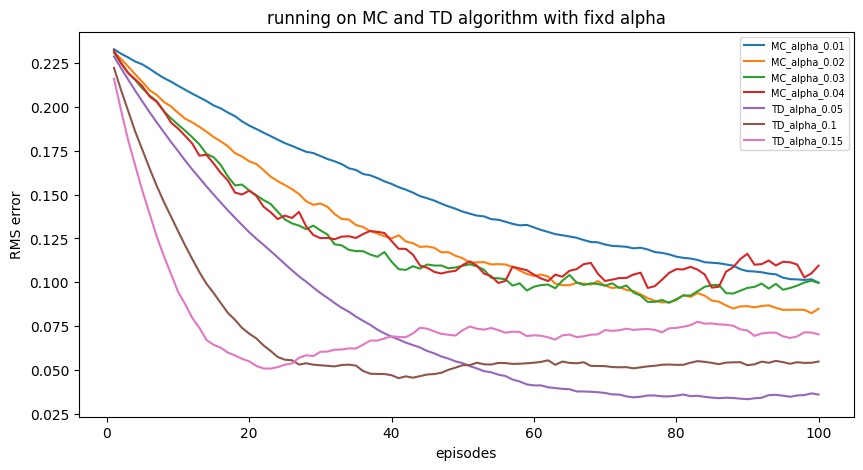

In [21]:
value=0.5
initial_value=[value]*5
env=RandomWalk()

max_episide=200

alpha_mc=[0.01,0.02,0.03,0.04]

alpha_td=[0.05,0.1,0.15]

average=100

mc_loss=[]
td_loss=[]
for j in range(len(alpha_mc)):
    mc_loss_=np.zeros((max_episide,))
    for i in range(average):
        t=run_mc_algo(alpha_mc[j],initial_value,max_episide,env)
        mc_loss_+=np.array([RMS_error(true_value,t[z]) for  z in range(max_episide)])/average

    mc_loss.append(list(mc_loss_))

for j in range(len(alpha_td)):
    td_loss_=np.zeros((max_episide,))
    for i in range(average):
        t=run_td_algo(alpha_td[j],1,initial_value,max_episide,env)
        td_loss_+=np.array([RMS_error(true_value,t[z]) for  z in range(max_episide)])/average

    td_loss.append(list(td_loss_))


x_axis = [i+1 for i in range(100)]
fig=plt.figure(figsize=(10,5))

plt.title("running on MC and TD algorithm with fixd alpha")
plt.xlabel("episodes")
plt.ylabel("RMS error")
for i in range(len(mc_loss)) :
    plt.plot(x_axis, mc_loss[i][:100],label="MC_alpha_"+str(alpha_mc[i]))
for i in range(len(td_loss)) :
    plt.plot(x_axis, td_loss[i][:100],label="TD_alpha_"+str(alpha_td[i]))
plt.legend(prop={"size":7})

**Questions**

- Discuss the impact of hyper-parameters like $\alpha$ to $MC$ and $TD$.
+ a lower $\alpha$ means that learning is more conservative, relying more heavily on past knowledge and changing more slowly over time.
+  A high $\alpha$ can cause the estimates to oscillate or diverge if too large, especially since MC updates are based on the full return (which can vary widely between episodes). 
+  For TD, $\alpha$ impacts how quickly the agent learns from each individual step within an episode.
- Discuss the difference between two algorithms.
+ They update the value function differently. MC algrithum need to get the $G_t$ to update the value function after thr whole episode, while TD alguithum can update the value function with the current reward the history value in the exactly current time step.

### 1.3 TD and MC algorithm with Exponential Moving Average alpha

There is an intuition in TD and MC learning: the data we get from later episodes are more time-efficient and important than earlier.

Hence, we take a dynamic alpha to verify this intuition.

When trying to update $V(S_{t})$ ,we take a time-varying learning rate $\alpha _{n} =\alpha _{0 }* \frac{1}{n}$ . **$n$ is the times of updating $V(S_{t})$**

You are required to implement the TD and MC algorithm with such a dynamic alpha in the following code.

As before, It returns a two-layer list $ans$, like [ [0,0,0,0,0], [0,0,0,0,0] ……].

The $i_{th}$ element of $ans$ means the value function after $i_{th}$ episodes iteration.

In [22]:
#############################
### mc algorithm
#############################

def run_mc_algo_dynamic_alpha(ini_alpha,initial_val,num_of_episodes,env:RandomWalk):
    """ YOUR CODE HERE """
    return_value_set=[[0,0,0,0,0] for _ in range(num_of_episodes)]
    for episode in range(num_of_episodes):
        state = env.start_id
        episode_transitions = []
        alpha = 1/(episode+1) * ini_alpha
        if episode == 0:
            return_value_set[episode] = copy.deepcopy(initial_val)
        else:
            return_value_set[episode] = copy.deepcopy(return_value_set[episode-1])
        # 生成当前episode的所有状态转换和奖励
        while True:
            next_state, reward = env.get_next_state_reward(state)
            if next_state is None:
                break
            episode_transitions.append((state, reward))
            state = next_state

        # 计算并更新每个状态的返回值G
        G = 0
        for transition in reversed(episode_transitions):
            state, reward = transition
            G = reward + G
            if state not in [env.state2id["terminal_0"], env.state2id["terminal_1"]]:
                return_value_set[episode][state-1] += alpha * (G - return_value_set[episode][state-1])


    """ END CODE HERE """
    return return_value_set


#############################
### td algorithm
#############################

def run_td_algo_dynamic_alpha(ini_alpha,gamma,initial_val,num_of_episodes,env:RandomWalk):
    """ YOUR CODE HERE """
    return_value_set=[[0,0,0,0,0] for _ in range(num_of_episodes)]

    for episode in range(num_of_episodes):
        current_state = env.start_id
        alpha = 1/(episode+1) * ini_alpha
        if episode == 0:
            return_value_set[episode][:] = initial_val
        else:
            return_value_set[episode][:] = return_value_set[episode-1][:]

        while current_state not in [env.state2id["terminal_0"], env.state2id["terminal_1"]]:
            next_state, reward = env.get_next_state_reward(current_state)
            next_state_val = 0 if next_state in [env.state2id["terminal_0"], env.state2id["terminal_1"]] else return_value_set[episode][next_state-1]
            return_value_set[episode][current_state-1] += alpha * (reward + gamma * next_state_val - return_value_set[episode][current_state-1])
            current_state = next_state   


    """ END CODE HERE """
    return return_value_set

### 1.4 Visualization the Influence of alpha

Here, we try to run two algorithms with dynamic alpha in our environment. You should run the following code without editing. **Your output will be one of the criteria we use to score**.

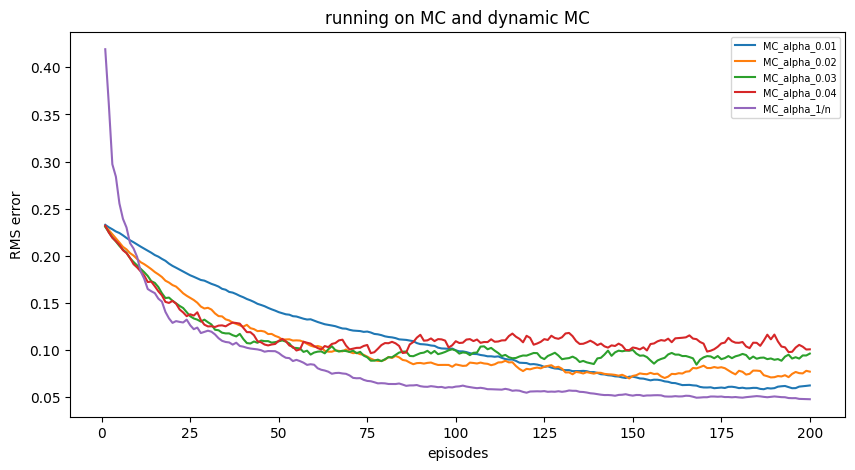

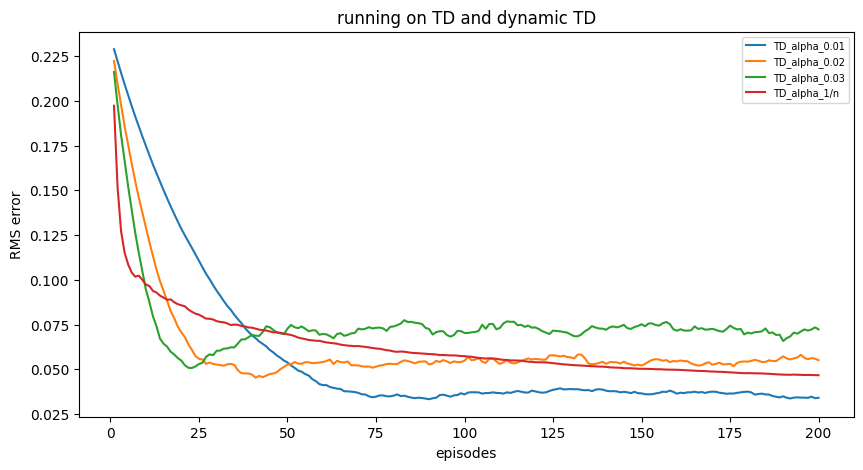

In [23]:
mc_loss_dynamic=[]
td_loss_dynamic=[]

mc_loss_=np.zeros((max_episide,))
for i in range(average):
    t=run_mc_algo_dynamic_alpha(1,initial_value,max_episide,env)
    mc_loss_+=np.array([RMS_error(true_value,t[z]) for  z in range(max_episide)])/average

mc_loss_dynamic=list(mc_loss_)

td_loss_=np.zeros((max_episide,))
for i in range(average):
    t=run_td_algo_dynamic_alpha(1,1,initial_value,max_episide,env)
    td_loss_+=np.array([RMS_error(true_value,t[z]) for  z in range(max_episide)])/average

td_loss_dynamic=list(td_loss_)


x_axis = [i+1 for i in range(max_episide)]
fig1=plt.figure(figsize=(10,5))
plt.title("running on MC and dynamic MC")
plt.xlabel("episodes")
plt.ylabel("RMS error")
for i in range(len(mc_loss)) :
    plt.plot(x_axis, mc_loss[i],label="MC_alpha_"+str(alpha_mc[i]))
plt.plot(x_axis,mc_loss_dynamic,label="MC_alpha_1/n")
plt.legend(prop={"size":7})

fig2=plt.figure(figsize=(10,5))
plt.title("running on TD and dynamic TD")
plt.xlabel("episodes")
plt.ylabel("RMS error")
for i in range(len(td_loss)) :
    plt.plot(x_axis, td_loss[i],label="TD_alpha_"+str(alpha_mc[i]))
plt.plot(x_axis,td_loss_dynamic,label="TD_alpha_1/n")
plt.legend(prop={"size":7})

**Questions**

- Discuss the impact of the exponential moving average alpha in TD and MC algorithm.
  
  With a high alpha, , more emphasis is placed on the most recent returns , which makes the value estimate more responsible for the new data, in the early stage of episode.
  
  With a low alpha, the updates are slower in the later stage of episode, and the history can be considered more.

## 2 Implementing SARSA and Q-Learning Algorithms in Cliff-Walking

In this part, you are required to implement the SARSA and Q-learning algorithms for the cliff-walking problem. 

### 2.1 Environment description

In this problem, the agent starts in the bottom left corner and is expected to reach the bottom right corner. Stepping into the cliff that segregates those tiles yields a massive negative reward and ends the episode. Otherwise, each step comes at a small cost, meaning the shortest path is the optimal policy (please see codes for more details).

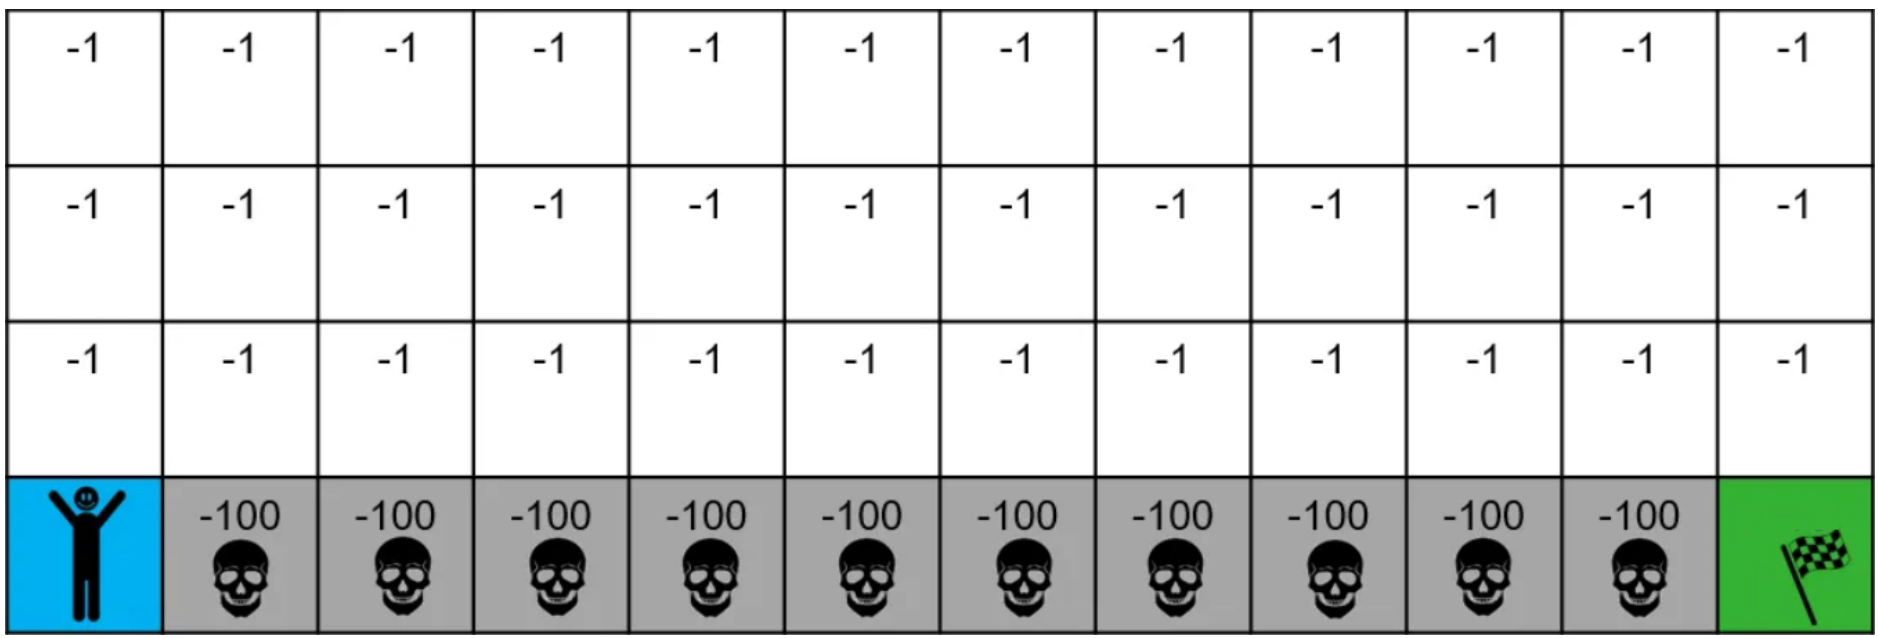


In [24]:
import time
import numpy as np

class Env():
    def __init__(self, length, height):
        self.length = length        
        self.height = height        
        self.x = 0                  
        self.y = 0                  

    def render(self, frames=50):
        for i in range(self.height):
            if i == 0: 
                line = ['S'] + ['x']*(self.length - 2) + ['T'] # the lower left corner is the start point, the lower right corner is the end point
            else:
                line = ['.'] * self.length # -1 reward
            if self.x == i:
                line[self.y] = 'o'
            print(''.join(line))
        print('\033['+str(self.height+1)+'A')  
        time.sleep(1.0 / frames)

    def step(self, action):
        """4 legal actions, 0:up, 1:down, 2:left, 3:right"""
        change = [[0, 1], [0, -1], [-1, 0], [1, 0]]

        tx, ty = self.x + change[action][0], self.y + change[action][1]
        self.x = min(self.height - 1, max(0, tx))
        self.y = min(self.length - 1, max(0, ty))

        states = [self.x, self.y]
        reward = -1
        terminal = False
        if self.x == 0: 
            if self.y > 0:
                terminal = True
                if self.y != self.length - 1:
                    reward = -100
        return reward, states, terminal

    def reset(self):
        self.x = 0
        self.y = 0

### 2.2 Implementing the $\epsilon$-greedy policy

Below is the base Q table for SARSA and Q-learning. 

**Coding exercise.** Please implement the $\epsilon$-greedy policy in `take_action()`.

In [25]:
class Base_Q_table():
    def __init__(self, length, height, actions=4, alpha=0.1, gamma=0.9, eps=0.1):
        self.table = [0] * actions * length * height
        self.actions = actions
        self.length = length
        self.height = height
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps

    def _index(self, a, x, y):
        return a * self.height * self.length + x * self.length + y

    def best_action(self, x, y):
        '''
        return: the best action of current position (x,y)
        '''
        mav = -100000
        mapos = -1
        change = [[0, 1], [0, -1], [-1, 0], [1, 0]]
        for i in range(self.actions):            
            tx, ty = x + change[i][0], y + change[i][1]
            if (min(tx, ty)<0 or tx>=self.height or ty>=self.length):
                continue
            if(self.table[self._index(i,x,y)] > mav):
                mav = self.table[self._index(i,x,y)]
                mapos = i
        return mapos

    def _epsilon(self, num_episode=0):
        return self.eps

    def max_q(self, x, y):
        action = self.best_action(x, y)
        return self.table[self._index(action,x,y)]
        
    def take_action(self, x, y, num_episode=1, method='eps_greedy'):
        '''
        method: 'eps_greedy' denotes that taking actions using epsilon greedy (used as the policy for SARSA, and the behavior policy for Q-Learning), 
        'full_greedy' denotes that taking actions fully greedy w.r.t. the current estimated Q table.
        '''

        """ YOUR CODE HERE """
        if method == 'eps_greedy':
            if np.random.random() < self._epsilon(num_episode):
                action = np.random.randint(0, self.actions)
            else:
                action = self.best_action(x, y)
        elif method == 'full_greedy':
            action = self.best_action(x, y)
        """ END """
        return action

    def update(self, direct, next_direct, s0, s1, reward, is_terminated):
        pass
        
    

### 2.3 Implementing the SARSA algorithm

**Coding exercise.**  In the following code, please implement the `update()` function, which updates the Q-table for SARSA, and the `cliff_walk()` function, which instantiates the SARSA algorithm.

In [27]:
class Q_table_sarsa(Base_Q_table):
    def __init__(self, length, height, actions=4, alpha=0.1, gamma=0.9, eps=0.1):
        super().__init__(length, height, actions, alpha = alpha, gamma = gamma, eps=eps)

    def update(self, direct, next_direct, s0, s1, reward, is_terminated):
        
        """ YOUR CODE HERE """
        if is_terminated:
            self.table[self._index(direct, s0[0], s0[1])] += self.alpha * (reward - self.table[self._index(direct,s0[0],s0[1])])
        else:
            self.table[self._index(direct, s0[0], s0[1])] += self.alpha * (reward + self.gamma * self.table[self._index(next_direct, s1[0], s1[1])] - self.table[self._index(direct, s0[0], s0[1])])
        return
    
    def cliff_walk(self):

        """ YOUR CODE HERE """
        rewards = []
        env = Env(length=12, height=4)
        num_episodes = 3000  # 总episode数量

        for episode in range(num_episodes):
            episodic_cumulative_reward = 0  
            is_terminated = False  
            s0 = [0, 0] 
            action = self.take_action(s0[0], s0[1], episode)  

            while not is_terminated:
                r, s1, is_terminated = env.step(action) 
                next_action = self.take_action(s1[0], s1[1], episode) 
                self.update(action, next_action, s0, s1, r, is_terminated)  
                s0, action = s1, next_action 
                episodic_cumulative_reward += r  

            rewards.append(episodic_cumulative_reward)  
            env.reset()  

        return rewards

### 2.4 Implementing the Q-learning algorithm

**Coding exercise.**  In the following code, please implement the `update()` function, which updates the Q-table for Q-learning, and the `cliff_walk()` function, which instantiates the Q-learning algorithm.

In [28]:
class Q_table_qlearning(Base_Q_table):
    def __init__(self, length, height, gamma, actions=4, alpha=0.005, eps=0.1):
        super().__init__(length, height, actions, alpha = alpha, gamma = gamma, eps=eps)

    def update(self, a, s0, s1, r, is_terminated):

        """ YOUR CODE HERE """
        if is_terminated:
            self.table[self._index(a, s0[0], s0[1])] += self.alpha * (r - self.table[self._index(a, s0[0], s0[1])])
        else:
            self.table[self._index(a, s0[0], s0[1])] += self.alpha * (r + self.gamma * self.max_q(s1[0], s1[1]) - self.table[self._index(a, s0[0], s0[1])])
        return
    
    def cliff_walk(self):
        
        """ YOUR CODE HERE """
        reward_eps_greedy, reward_full_greedy = [], []
        env = Env(length=12, height=4)
        for num_episode in range(3000): 
            s0 = [0, 0]
            episodic_cumulative_reward = 0
            is_terminated = False
            while not is_terminated:
                action = self.take_action(s0[0], s0[1], num_episode, method='eps_greedy')
                r, s1, is_terminated = env.step(action)
                self.update(action, s0, s1, r, is_terminated)
                s0 = s1
                episodic_cumulative_reward += r
            reward_eps_greedy.append(episodic_cumulative_reward)
            env.reset()
            
            ## fully_greedy
            s0 = [0, 0]
            episodic_cumulative_reward = 0
            is_terminated = False
            while not is_terminated:
                action = self.take_action(s0[0], s0[1], num_episode, method='full_greedy')
                r, s1, is_terminated = env.step(action)
                self.update(action, s0, s1, r, is_terminated)
                s0 = s1
                episodic_cumulative_reward += r
            reward_full_greedy.append(episodic_cumulative_reward)
            env.reset()

        return reward_eps_greedy, reward_full_greedy

### 2.5 Comparing the performance

Please run the following code to evaluate SARSA and Q-learning with different values of $\epsilon$ in $\epsilon$-greedy. You need to show

- the performance of the SARSA algorithm with different values of $\epsilon$ in $\epsilon$-greedy;
- the performance of the Q-learning algorithm with different values of $\epsilon$ in $\epsilon$-greedy;
- the performance of Q-learning algorithm with different values of $\epsilon$ in $\epsilon$-greedy but using the **target policy** (*i.e.*, the learned optimal policy in each episode).

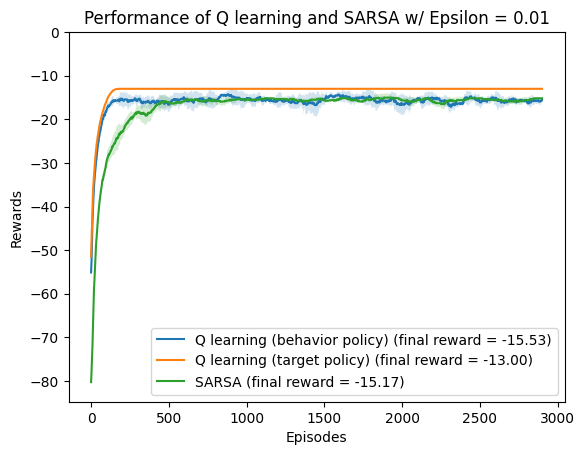

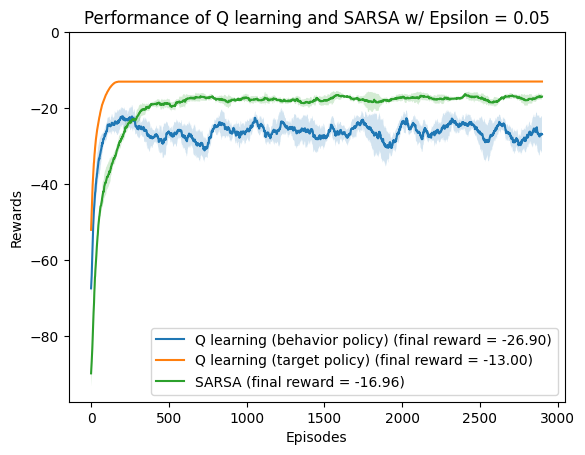

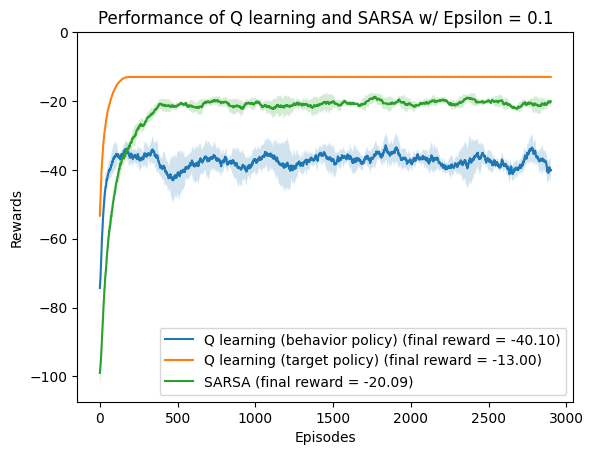

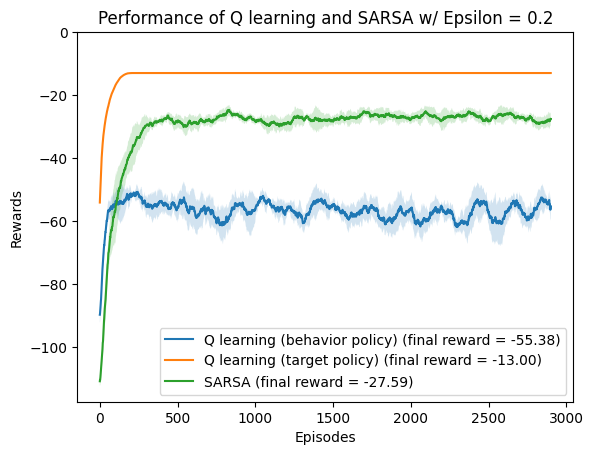

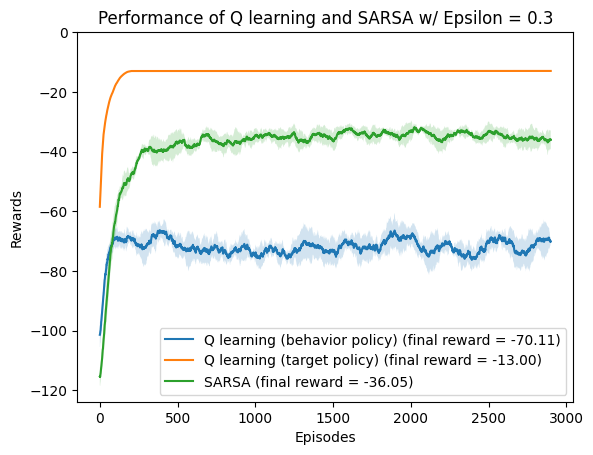

<Figure size 640x480 with 0 Axes>

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_moving_average(data, label, window_size=100):
    def moving_average(x, w):
        return np.convolve(x, np.ones(w), 'valid') / w
    moving_averages = np.array([moving_average(row, window_size) for row in data])
    mean_moving_averages = moving_averages.mean(axis=0)
    std_dev_moving_averages = moving_averages.std(axis=0)
    plt.plot(mean_moving_averages, label=f"{label} (final reward = {mean_moving_averages[-1]:.2f})")
    plt.fill_between(range(len(mean_moving_averages)),
                     mean_moving_averages - std_dev_moving_averages,
                     mean_moving_averages + std_dev_moving_averages, 
                     alpha=0.2)


height, length = 4, 12
gamma = 0.95
alpha = 0.1
eps_list = [0.01, 0.05, 0.1, 0.2, 0.3]
reward_qlearning_behavior_policys = {}
reward_qlearning_target_policys = {}
reward_sarsas = {}
for eps in eps_list:
    reward_qlearning_behavior_policys[eps] = []
    reward_qlearning_target_policys[eps] = []
    reward_sarsas[eps] = []
for eps in eps_list:
    seeds = [42, 43, 44, 45, 46]
    for seed in seeds:
        agent = Q_table_qlearning(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
        reward_qlearning_behavior_policy, reward_qlearning_target_policy = agent.cliff_walk()
        reward_qlearning_behavior_policys[eps].append(reward_qlearning_behavior_policy)
        reward_qlearning_target_policys[eps].append(reward_qlearning_target_policy)
        agent = Q_table_sarsa(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
        reward_sarsa = agent.cliff_walk()
        reward_sarsas[eps].append(reward_sarsa)


for eps in eps_list:
    plot_moving_average(reward_qlearning_behavior_policys[eps], f"Q learning (behavior policy)")
    plot_moving_average(reward_qlearning_target_policys[eps], f"Q learning (target policy)")
    plot_moving_average(reward_sarsas[eps], f"SARSA")
    plt.xlabel("Episodes")
    plt.ylabel("Rewards")
    plt.title(f"Performance of Q learning and SARSA w/ Epsilon = {eps}")
    plt.legend()
    plt.ylim(None, 0)
    plt.show()
    plt.clf()


**Questions.**  Please compare the performance of the algorithms in the above cases and give discussions about

- What are the impacts of different values of $\epsilon$ on the performance of the above three algorithms? Explain the reasons.
  
ϵ增大，三种算法的收敛更快，rewards变少。
低 ϵ 表示策略更倾向于利用当前知识来做决策，探索较少，在初期可能导致性能不佳，因为算法可能错过了更优的行动方案。
高 ϵ 鼓励算法大量探索新行为，可能在短期内降低性能，因为算法花费更多时间尝试较差的行动。

- Discuss the difference between SARAS and Q-learning algorithms. Why is SARAR called an on-policy algorithm and the Q-learning algorithm called an off-policy one?

Q learning update the Q function without using the next action or the current policy, while Sarse using the next action based on the current policy.

- What is the difference between the performance of the **behavior policy** of Q-learning algorithm and the performance of the **target policy** of Q-learning algorithm? Explain the reasons.
行为策略在学习过程中找到一个平衡，以探索未知的行动和利用已知的最佳行动之间。这可能导致学习过程中的即时回报较低，但有助于长期发现最优策略。目标策略直接利用了所有的学习成果， 不完全探索时效果优于行为策略。

### 2.6 Trajectory Visualization and Discussion of the Learned Policies

Please print out the actions under different states for the policy finally learned by SARSA and Q-learning and analyze why such results were obtained. For instance, explore whether the policy learned by different algorithms varies and the reasons behind these differences.

In [30]:
def print_policy(policy):
    states = [[-1 for _ in range(12)] for _ in range(4)]
    arrow_mapping = {
        -1: '.',
        0: '\u2192',
        1: '\u2190',
        2: '\u2193',
        3: '\u2191'
    }
    env = Env(length=12, height=4)
    is_terminated = False
    s0 = [0, 0]
    record = []
    action = policy.take_action(s0[0], s0[1], 1)
    while not is_terminated:
        _, s1, is_terminated = env.step(action)
        if s0 != s1:
            record.append((s0, action))
        next_action = policy.take_action(s1[0], s1[1], 1)
        s0 = s1
        action = next_action
    for r in record:
        (x, y), a = r
        states[x][y] = a
    for x in range(3, -1, -1):
        for y in range(12):
            print(arrow_mapping[states[x][y]], end='')
        print()
    return 

def print_best_action_policy(policy):
    states = [[-1 for _ in range(12)] for _ in range(4)]
    arrow_mapping = {
        -1: '.',
        0: '\u2192',
        1: '\u2190',
        2: '\u2193',
        3: '\u2191'
    }
    env = Env(length=12, height=4)
    is_terminated = False
    s0 = [0, 0]
    record = []
    action = policy.best_action(s0[0], s0[1])
    while not is_terminated:
        _, s1, is_terminated = env.step(action)
        if s0 != s1:
            record.append((s0, action))
        next_action = policy.best_action(s1[0], s1[1])
        s0 = s1
        action = next_action
    for r in record:
        (x, y), a = r
        states[x][y] = a
    for x in range(3, -1, -1):
        for y in range(12):
            print(arrow_mapping[states[x][y]], end='')
        print()
    return

In [31]:
# For Q-learning (behavior policy):
eps_list = [0.0, 0.1, 0.2, 0.3]
for eps in eps_list:
    agent = Q_table_qlearning(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
    agent.cliff_walk()
    print(f"Q learning (behavior) policy w/ epsilon = {eps}:")
    print_policy(agent)

Q learning (behavior) policy w/ epsilon = 0.0:
............
............
→→→→→→→→→→→↓
↑...........
Q learning (behavior) policy w/ epsilon = 0.1:
............
............
→→→→→→→→→→→↓
↑...........
Q learning (behavior) policy w/ epsilon = 0.2:
...........↓
..........→↓
→→→→→→→→→→↑↓
↑...........
Q learning (behavior) policy w/ epsilon = 0.3:
............
............
→→→→→→→↓....
↑...........


In [32]:
# For Q-learning (target policy):
eps_list = [0.0, 0.1, 0.2, 0.3]
for eps in eps_list:
    agent = Q_table_qlearning(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
    agent.cliff_walk()
    print(f"Q learning (target) policy w/ epsilon = {eps}:")
    print_best_action_policy(agent)

Q learning (target) policy w/ epsilon = 0.0:
............
............
→→→→→→→→→→→↓
↑...........
Q learning (target) policy w/ epsilon = 0.1:
............
............
→→→→→→→→→→→↓
↑...........
Q learning (target) policy w/ epsilon = 0.2:
............
............
→→→→→→→→→→→↓
↑...........
Q learning (target) policy w/ epsilon = 0.3:
............
............
→→→→→→→→→→→↓
↑...........


In [33]:
# For SARSA:
eps_list = [0.0, 0.1, 0.2, 0.3]
for eps in eps_list:
    agent = Q_table_sarsa(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
    agent.cliff_walk()
    print(f"SARSA policy w/ epsilon = {eps}:")
    print_policy(agent)

SARSA policy w/ epsilon = 0.0:
............
............
→→→→→→→→→→→↓
↑...........
SARSA policy w/ epsilon = 0.1:
............
.→→→→→→↓....
→↑.....↓....
↑...........
SARSA policy w/ epsilon = 0.2:
→→→→↓.......
↑...→→→→→→→↓
↑......↑...↓
↑...........
SARSA policy w/ epsilon = 0.3:
→→→→→→→→→→→↓
↑←.........↓
→↑.........↓
↑...........


In [24]:
# For SARSA (argmax policy):
eps_list = [0.0, 0.1, 0.2, 0.3]
for eps in eps_list:
    agent = Q_table_sarsa(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
    agent.cliff_walk()
    print(f"SARSA argmax policy w/ epsilon = {eps}:")
    print_best_action_policy(agent)

SARSA argmax policy w/ epsilon = 0.0:
............
............
→→→→→→→→→→→↓
↑...........
SARSA argmax policy w/ epsilon = 0.1:
→→→→→→→↓....
↑......→→→→↓
↑..........↓
↑...........
SARSA argmax policy w/ epsilon = 0.2:
→→→→→→→→→→→↓
↑..........↓
↑..........↓
↑...........
SARSA argmax policy w/ epsilon = 0.3:
→→→→→→→→→→→↓
↑..........↓
↑..........↓
↑...........


Specifically, here we define four policies:

1. $\pi_1$: a safer policy from the starting point to the target, and when not in the trajectory, the agent will go towards the trajectory (trajectory is shown in the figure below, and please refer to `Pi_1` for the implementation);
2. $\pi_2$: a more radical policy from the starting point to the target and when not in the trajectory, the agent will go towards the trajectory (trajectory is shown in the figure below, and please refer to `Pi_2` for the implementation);
3. $\pi_3$: $\pi_1$, but with a probability of $0.2$ to go randomly at each step (please refer to `Pi_3` for the implementation);
4. $\pi_4$: $\pi_2$, but with a probability of $0.2$ to go randomly at each step (please refer to `Pi_4` for the implementation).

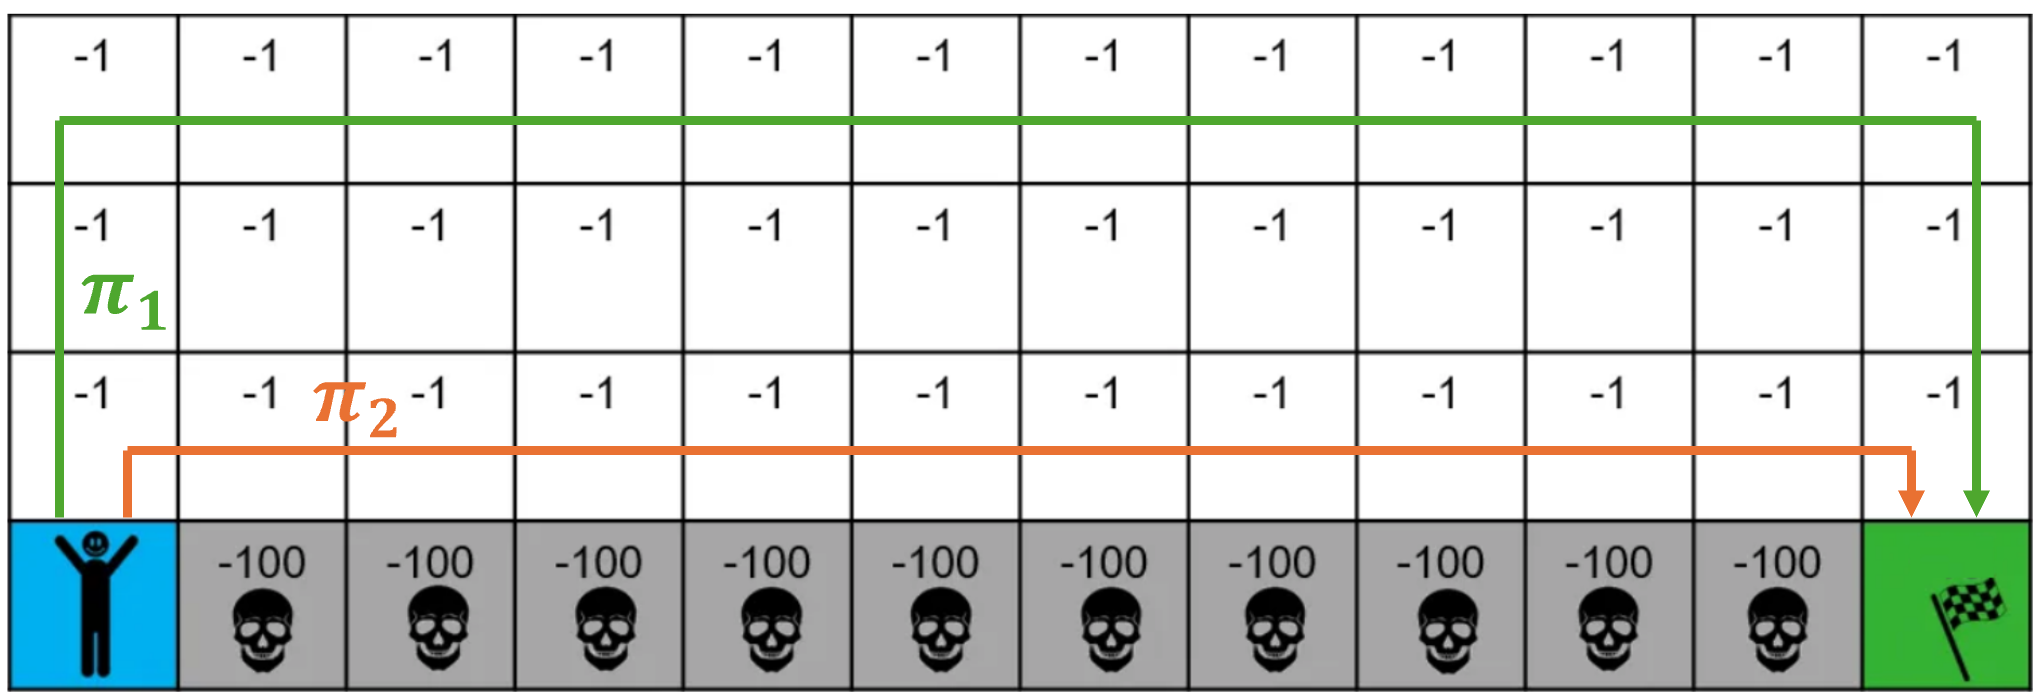


In [34]:
import random

class Pi_1:
    def __init__(self):
        self.action_table = [
            [+3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, +2],
            [+3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +2],
            [+3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +2],
            [+0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +2],
        ]
    def take_action(self, x, y):
        return self.action_table[x][y]

class Pi_2:
    def __init__(self):
        self.action_table = [
            [+3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, +2],
            [+0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +2],
            [+2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2],
            [+2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2],
        ]
    def take_action(self, x, y):
        return self.action_table[x][y]


class Pi_3:
    def __init__(self):
        self.action_table = [
            [+3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, +2],
            [+3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +2],
            [+3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +3, +2],
            [+0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +2],
        ]
    def take_action(self, x, y):
        if random.uniform(0, 1) < 0.2 or self.action_table[x][y] == -1:
            return random.randint(0, 3)
        else:
            return self.action_table[x][y]


class Pi_4:
    def __init__(self):
        self.action_table = [
            [+3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, +2],
            [+0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +0, +2],
            [+2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2],
            [+2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2, +2],
        ]
    def take_action(self, x, y):
        if random.uniform(0, 1) < 0.2 or self.action_table[x][y] == -1:
            return random.randint(0, 3)
        else:
            return self.action_table[x][y]

pi_1 = Pi_1()
pi_2 = Pi_2()
pi_3 = Pi_3()
pi_4 = Pi_4()

Please complete the function `compute_Q_table` below, which will recalculate the Q table under a given policy. We will use this function to compute the Q tables for pi_1, pi_2, pi_3, and pi_4, as well as recalculate the Q tables corresponding to the policies ultimately learned through the SARSA policy, Q learning behavior policy, and Q learning target policy. You may refer to the following equation during your recursive computation:
$$
Q^\pi(s,a) = \sum_{s'}T(s,a,s')\left[R(s,a,s') + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s',a')\right]
$$

In [38]:
def compute_Q_table(q_table, policy, num_episodes=10000, next_action_sample_size=40):

    """ YOUR CODE HERE """
    ## TD
    env = Env(length=12, height=4)
    for _ in range(num_episodes):
        s = [0,0]
        is_terminal = False
        episode = []
        G = 0
        for _ in range(next_action_sample_size):
            action = policy.take_action(s[0], s[1])
            reward, state, terminal = env.step(action)
            episode.append((action, state, reward))
            if terminal:
                break
            s = state
            
        for j in range(len(episode)-1, -1, -1):
            action, next_state, reward = episode[j]
            G = reward + gamma*G
            q_table.table[q_table._index(action, next_state[0], next_state[1])] = (G - q_table.table[q_table._index(action, next_state[0], next_state[1])]) * alpha + q_table.table[q_table._index(action, next_state[0], next_state[1])]

    
    return q_table


q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
policy1_table = np.array(compute_Q_table(q_table, pi_1).table)
q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
policy2_table = np.array(compute_Q_table(q_table, pi_2).table)
q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
policy3_table = np.array(compute_Q_table(q_table, pi_3).table)
q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
policy4_table = np.array(compute_Q_table(q_table, pi_4).table)

q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
agent = Q_table_sarsa(height = height, length = length, gamma = gamma, eps = 0.2, alpha = alpha)
agent.cliff_walk()
SARSA_table = np.array(compute_Q_table(q_table, agent).table)

q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
agent = Q_table_qlearning(height = height, length = length, gamma = gamma, eps = eps, alpha = alpha)
agent.cliff_walk()
Q_learning_behavior_table = np.array(compute_Q_table(q_table, agent).table)


class Q_learning_target:
    def __init__(self, agent):
        self.agent = agent
    def take_action(self, x, y):
        return self.agent.best_action(x, y)
q_table = Base_Q_table(12, 4, gamma=0.95, eps=eps, alpha=0.1)
Q_learning_target_table = np.array(compute_Q_table(q_table, Q_learning_target(agent)).table)


def compare_Q_tables(table1, table2):
    return np.average(abs(np.array(table1) - np.array(table2)))


print("Comparing SARSA Q table with pre-defined policies:")
print("With pi_1: ", compare_Q_tables(SARSA_table, policy1_table))
print("With pi_2: ", compare_Q_tables(SARSA_table, policy2_table))
print("With pi_3: ", compare_Q_tables(SARSA_table, policy3_table))
print("With pi_4: ", compare_Q_tables(SARSA_table, policy4_table))

print("Comparing Q-learning behavior table with pre-defined policies:")
print("With pi_1: ", compare_Q_tables(Q_learning_behavior_table, policy1_table))
print("With pi_2: ", compare_Q_tables(Q_learning_behavior_table, policy2_table))
print("With pi_3: ", compare_Q_tables(Q_learning_behavior_table, policy3_table))
print("With pi_4: ", compare_Q_tables(Q_learning_behavior_table, policy4_table))

print("Comparing Q-learning target table with pre-defined policies:")
print("With pi_1: ", compare_Q_tables(Q_learning_target_table, policy1_table))
print("With pi_2: ", compare_Q_tables(Q_learning_target_table, policy2_table))
print("With pi_3: ", compare_Q_tables(Q_learning_target_table, policy3_table))
print("With pi_4: ", compare_Q_tables(Q_learning_target_table, policy4_table))

Comparing SARSA Q table with pre-defined policies:
With pi_1:  2.4901654044350274
With pi_2:  2.575001030664548
With pi_3:  0.8557248259620268
With pi_4:  1.9964334996953095
Comparing Q-learning behavior table with pre-defined policies:
With pi_1:  5.117024825837188
With pi_2:  5.055972392528723
With pi_3:  2.8853418364912833
With pi_4:  2.2557077444521507
Comparing Q-learning target table with pre-defined policies:
With pi_1:  0.08983823039618725
With pi_2:  0.0
With pi_3:  3.108709882452706
With pi_4:  3.7141744181607



In the code above, we utilize the `compare_Q_tables` function to assess the similarity among different Q tables. Specifically, we evaluate the similarity of the SARSA Q table, Q learning behavior policy Q table, and Q learning target policy Q table against pi_1, pi_2, pi_3, and pi_4. 

**Questions.** Based on this analysis, please answer the following questions:

- Determine that the Q-table of the SARSA (Q-learning (behavior); Q-learning (behavior)) algorithm is most consistent with the Q table of which algorithm we manually defined. You may draw conclusions from various perspectives, such as the visualized trajectories and the degree of similarity in the Q tables. 
  
- Please provide a detailed analysis of the reasons behind these results.

SARSA 与pi 3相似，符合pi_3策略中以0.2的概率随机游走的情况。探索充分。
Q-learning (behavior)和pi_4策略相似，探索过多，轨迹混乱。
Q-learning（target）和pi_2相似，没有过多探索，容易收敛。


SARSA算法作为同策略学习算法，其学习过程中考虑了行动的风险，因此可能倾向于更保守的策略